# L63 Forecasting Examples with `predict_times`

This notebook shows how to run forecasting with known L63 parameters using `Predictive` and a `predict_times` argument at the model level (forwarded to `dsx.sample(..., predict_times=...)`).

We cover:

1. SDE + `Filter(ContinuousTimeEnKFConfig)`
2. ODE + `ODESimulator`
3. SDE + `SDESimulator`
4. `Discretizer` (Euler-Maruyama) + `DiscreteTimeSimulator`

For each case we plot:

- observation-time window (`obs_times`) and observations (`obs_values`),
- fitted/filtered trajectory on observation window,
- forecast trajectory on prediction window (`predict_times`),
- uncertainty bands.

For simulator-based examples we estimate uncertainty from multiple predictive draws.

In [1]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro.distributions as dist
import optax
from numpyro.infer import Predictive, SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoDiagonalNormal

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    DiscreteTimeSimulator,
    Discretizer,
    Filter,
    LinearGaussianObservation,
    ODESimulator,
    SDESimulator,
)
from dynestyx.inference.filter_configs import ContinuousTimeEnKFConfig

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

In [2]:
# Known (fixed) L63 parameter and model constants
RHO_TRUE = 28.0
SIGMA = 10.0
BETA = 8.0 / 3.0
OBS_NOISE = 0.5


def l63_dynamics(rho: float = RHO_TRUE) -> DynamicalModel:
    state_dim = 3
    observation_dim = 1

    def drift(x, u, t):
        del u, t
        return jnp.array(
            [
                SIGMA * (x[1] - x[0]),
                x[0] * (rho - x[2]) - x[1],
                x[0] * x[1] - BETA * x[2],
            ]
        )

    return DynamicalModel(
        state_dim=state_dim,
        observation_dim=observation_dim,
        control_dim=0,
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(state_dim),
            covariance_matrix=2.0**2 * jnp.eye(state_dim),
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=drift,
            diffusion_coefficient=lambda x, u, t: jnp.eye(state_dim),
            bm_dim=state_dim,
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.array([[1.0, 0.0, 0.0]]),
            R=jnp.array([[OBS_NOISE**2]]),
        ),
    )


def model_sde_filter(obs_times=None, obs_values=None, predict_times=None):
    dynamics = l63_dynamics()
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


def model_ode_sim(obs_times=None, obs_values=None, predict_times=None):
    dynamics = l63_dynamics()
    # ODE path: remove diffusion for deterministic dynamics
    dynamics = DynamicalModel(
        state_dim=dynamics.state_dim,
        observation_dim=dynamics.observation_dim,
        control_dim=dynamics.control_dim,
        initial_condition=dynamics.initial_condition,
        state_evolution=ContinuousTimeStateEvolution(
            drift=dynamics.state_evolution.drift,
            diffusion_coefficient=None,
        ),
        observation_model=dynamics.observation_model,
    )
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


def model_sde_sim(obs_times=None, obs_values=None, predict_times=None):
    dynamics = l63_dynamics()
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


def model_sde_discretized(obs_times=None, obs_values=None, predict_times=None):
    dynamics = l63_dynamics()
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )

In [3]:
# Shared time grids and synthetic data generation
obs_times = jnp.arange(0.0, 6.0, 0.05)
predict_times = jnp.arange(float(obs_times[-1]) + 0.05, 8.0, 0.05)

rng_key = jr.PRNGKey(0)
data_key, _ = jr.split(rng_key)

# Generate one synthetic dataset at observation times only.
with SDESimulator():
    synthetic = Predictive(
        model_sde_sim,
        num_samples=1,
        exclude_deterministic=False,
    )(data_key, obs_times=obs_times)

obs_values = synthetic["observations"][0]

print("obs_times:", obs_times.shape)
print("predict_times:", predict_times.shape)
print("obs_values:", obs_values.shape)

obs_times: (120,)
predict_times: (40,)
obs_values: (120, 1)


In [4]:
def _plot_filter_forecast(
    title,
    obs_times,
    obs_values,
    filtered_mean,
    forecast_mean,
    forecast_cov,
):
    y_obs = jnp.asarray(obs_values).squeeze()
    t_obs = jnp.asarray(obs_times)
    t_pred = jnp.asarray(predict_times)

    filt = jnp.asarray(filtered_mean)[:, 0]
    pred = jnp.asarray(forecast_mean)[:, 0]
    pred_std = jnp.sqrt(jnp.asarray(forecast_cov)[:, 0, 0])

    plt.figure()
    plt.scatter(t_obs, y_obs, s=8, alpha=0.7, label="observations")
    plt.plot(t_obs, filt, lw=2, label="filtered mean")
    plt.plot(t_pred, pred, lw=2, linestyle="--", label="forecast mean")
    plt.fill_between(
        t_pred,
        pred - 2.0 * pred_std,
        pred + 2.0 * pred_std,
        alpha=0.2,
        label="forecast ±2 std",
    )
    plt.axvline(float(t_obs[-1]), color="k", linestyle=":", lw=1)
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("y")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()


def _plot_simulator_forecast_from_draws(
    title,
    obs_times,
    obs_values,
    pred_times,
    obs_draws,
    pred_draws,
):
    y_obs = jnp.asarray(obs_values).squeeze()
    t_obs = jnp.asarray(obs_times)
    t_pred = jnp.asarray(pred_times)

    obs_draws_1d = jnp.asarray(obs_draws).squeeze(-1)
    pred_draws_1d = jnp.asarray(pred_draws).squeeze(-1)

    obs_mean = obs_draws_1d.mean(axis=0)
    obs_std = obs_draws_1d.std(axis=0)
    pred_mean = pred_draws_1d.mean(axis=0)
    pred_std = pred_draws_1d.std(axis=0)

    plt.figure()
    plt.scatter(t_obs, y_obs, s=8, alpha=0.7, label="observations")

    plt.plot(t_obs, obs_mean, lw=2, label="sim fit mean")
    plt.fill_between(
        t_obs,
        obs_mean - 2.0 * obs_std,
        obs_mean + 2.0 * obs_std,
        alpha=0.2,
        label="sim fit ±2 std",
    )

    plt.plot(t_pred, pred_mean, lw=2, linestyle="--", label="forecast mean")
    plt.fill_between(
        t_pred,
        pred_mean - 2.0 * pred_std,
        pred_mean + 2.0 * pred_std,
        alpha=0.2,
        label="forecast ±2 std",
    )

    plt.axvline(float(t_obs[-1]), color="k", linestyle=":", lw=1)
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("y")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

## 1) SDE with EnKF filter

We run a single predictive draw under `Filter(ContinuousTimeEnKFConfig)`.

The filter returns deterministic sites:

- `f_filtered_states_mean`
- `f_forecasted_state_means`
- `f_forecasted_state_covs`

which we use to plot mean and forecast uncertainty bands.

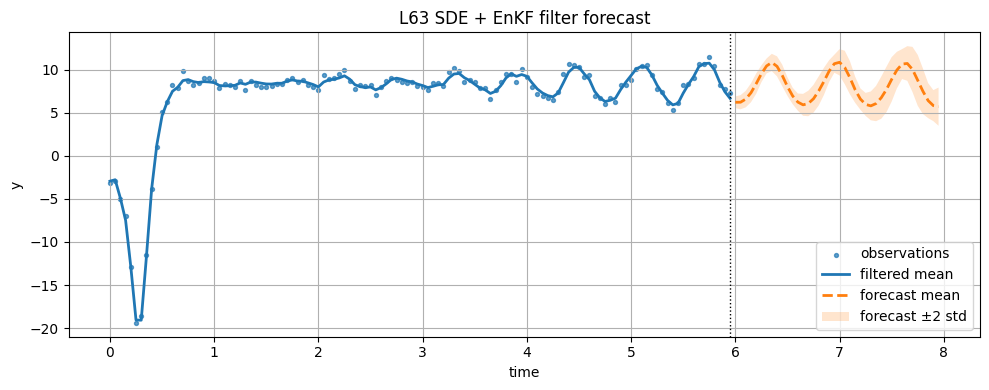

In [5]:
enkf_key = jr.PRNGKey(11)
with Filter(filter_config=ContinuousTimeEnKFConfig(n_particles=64)):
    enkf_out = Predictive(
        model_sde_filter,
        num_samples=1,
        exclude_deterministic=False,
    )(
        enkf_key,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )

_plot_filter_forecast(
    "L63 SDE + EnKF filter forecast",
    obs_times,
    obs_values,
    enkf_out["f_filtered_states_mean"][0],
    enkf_out["f_forecasted_state_means"][0],
    enkf_out["f_forecasted_state_covs"][0],
)

## 2) ODE with `ODESimulator`

For simulator-based forecasting, we first run SVI conditioned on `obs_values` to infer the latent state posterior over the observation window. Then we run posterior predictive draws with `predict_times` to roll those inferred states forward.

100%|██████████| 1500/1500 [04:33<00:00,  5.49it/s, init loss: 70166.6953, avg. loss [1426-1500]: 266.5129]


ODE SVI final ELBO: 258.27313232421875


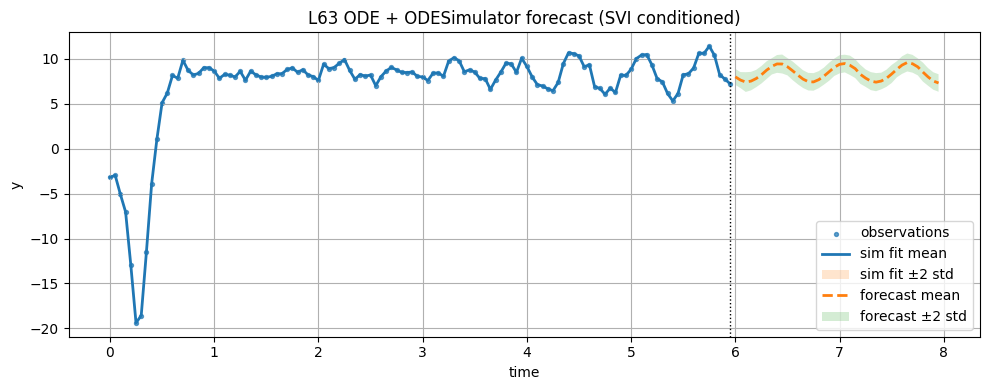

In [6]:
ode_svi_steps = 1500
ode_num_posterior_samples = 300

ode_guide = AutoDiagonalNormal(model_ode_sim)
ode_svi = SVI(model_ode_sim, ode_guide, optax.adam(1e-2), loss=Trace_ELBO())

with ODESimulator():
    ode_svi_result = ode_svi.run(
        jr.PRNGKey(21),
        ode_svi_steps,
        obs_times=obs_times,
        obs_values=obs_values,
    )
    ode_posterior = ode_guide.sample_posterior(
        jr.PRNGKey(22),
        ode_svi_result.params,
        sample_shape=(ode_num_posterior_samples,),
    )
    ode_out = Predictive(
        model_ode_sim,
        posterior_samples=ode_posterior,
        exclude_deterministic=False,
    )(
        jr.PRNGKey(23),
        obs_times=obs_times,
        predict_times=predict_times,
    )

print("ODE SVI final ELBO:", float(ode_svi_result.losses[-1]))

_plot_simulator_forecast_from_draws(
    "L63 ODE + ODESimulator forecast (SVI conditioned)",
    obs_times,
    obs_values,
    ode_out["prediction_times"][0],
    ode_out["observations"],
    ode_out["predicted_observations"],
)

## 3) SDE with `SDESimulator`

As in the ODE case, we fit an SVI posterior conditioned on observations first, then generate posterior predictive trajectories for both fit and forecast windows.

100%|██████████| 10/10 [00:58<00:00,  5.89s/it, init loss: 66820.6484, avg. loss [10-10]: 68107.0234]


SDE SVI final ELBO: 68107.0234375


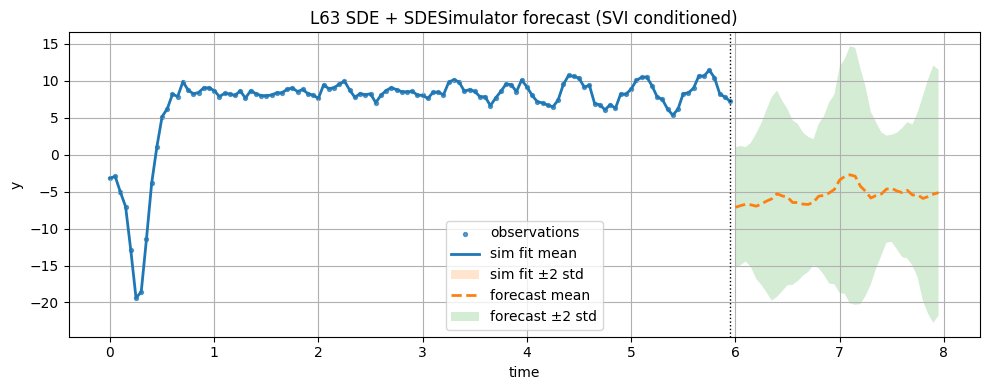

In [7]:
sde_svi_steps = 10
sde_num_posterior_samples = 10

sde_guide = AutoDiagonalNormal(model_sde_sim)
sde_svi = SVI(model_sde_sim, sde_guide, optax.adam(5e-3), loss=Trace_ELBO())

with SDESimulator():
    sde_svi_result = sde_svi.run(
        jr.PRNGKey(31),
        sde_svi_steps,
        obs_times=obs_times,
        obs_values=obs_values,
    )
    sde_posterior = sde_guide.sample_posterior(
        jr.PRNGKey(32),
        sde_svi_result.params,
        sample_shape=(sde_num_posterior_samples,),
    )
    sde_out = Predictive(
        model_sde_sim,
        posterior_samples=sde_posterior,
        exclude_deterministic=False,
    )(
        jr.PRNGKey(33),
        obs_times=obs_times,
        predict_times=predict_times,
    )

print("SDE SVI final ELBO:", float(sde_svi_result.losses[-1]))

_plot_simulator_forecast_from_draws(
    "L63 SDE + SDESimulator forecast (SVI conditioned)",
    obs_times,
    obs_values,
    sde_out["prediction_times"][0],
    sde_out["observations"],
    sde_out["predicted_observations"],
)

## 4) Euler-Maruyama Discretizer + `DiscreteTimeSimulator`

We discretize the continuous-time L63 dynamics, fit an SVI posterior conditioned on observations on the discrete grid, then draw posterior predictive trajectories for forecasting.

100%|██████████| 1200/1200 [00:00<00:00, 1265.84it/s, init loss: 55087.3945, avg. loss [1141-1200]: 18469.0762]


Discrete SVI final ELBO: 18438.537109375
Discrete simulator finite checks:
  states finite: True
  predicted_states finite: True
  predicted_observations finite: True


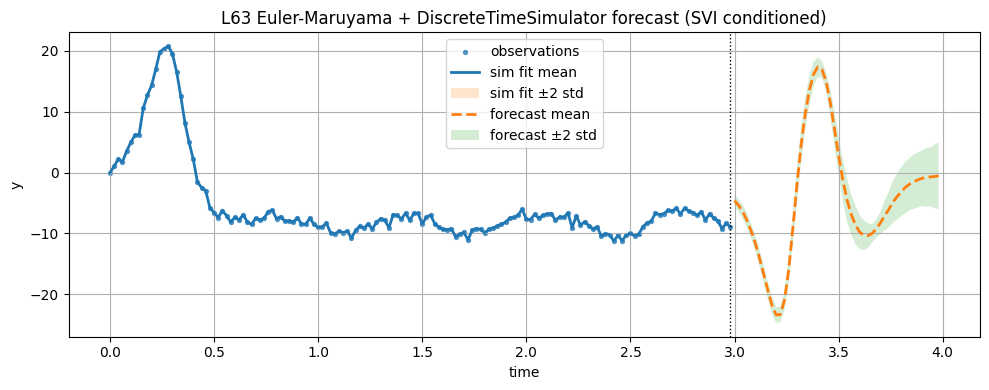

In [8]:
# Euler-Maruyama at dt=0.05 can be unstable for chaotic L63 over longer windows.
# Use a finer grid in this section.
disc_obs_times = jnp.arange(0.0, 3.0, 0.02)
disc_predict_times = jnp.arange(float(disc_obs_times[-1]) + 0.02, 4.0, 0.02)

# Build observations on the same grid used by the discretized simulator.
with SDESimulator():
    disc_synthetic = Predictive(
        model_sde_sim,
        num_samples=1,
        exclude_deterministic=False,
    )(
        jr.PRNGKey(40),
        obs_times=disc_obs_times,
    )
disc_obs_values = disc_synthetic["observations"][0]

disc_svi_steps = 1200
disc_num_posterior_samples = 200

disc_guide = AutoDiagonalNormal(model_sde_discretized)
disc_svi = SVI(model_sde_discretized, disc_guide, optax.adam(1e-2), loss=Trace_ELBO())

with DiscreteTimeSimulator():
    with Discretizer():
        disc_svi_result = disc_svi.run(
            jr.PRNGKey(41),
            disc_svi_steps,
            obs_times=disc_obs_times,
            obs_values=disc_obs_values,
        )
        disc_posterior = disc_guide.sample_posterior(
            jr.PRNGKey(42),
            disc_svi_result.params,
            sample_shape=(disc_num_posterior_samples,),
        )
        disc_out = Predictive(
            model_sde_discretized,
            posterior_samples=disc_posterior,
            exclude_deterministic=False,
        )(
            jr.PRNGKey(43),
            obs_times=disc_obs_times,
            predict_times=disc_predict_times,
        )

print("Discrete SVI final ELBO:", float(disc_svi_result.losses[-1]))
print("Discrete simulator finite checks:")
print("  states finite:", bool(jnp.isfinite(disc_out["states"]).all()))
print("  predicted_states finite:", bool(jnp.isfinite(disc_out["predicted_states"]).all()))
print("  predicted_observations finite:", bool(jnp.isfinite(disc_out["predicted_observations"]).all()))

_plot_simulator_forecast_from_draws(
    "L63 Euler-Maruyama + DiscreteTimeSimulator forecast (SVI conditioned)",
    disc_obs_times,
    disc_obs_values,
    disc_out["prediction_times"][0],
    disc_out["observations"],
    disc_out["predicted_observations"],
)